# Consensus clustering


This notebook demonstrates how to perform consensus clustering using TOAD. After running TOAD on multiple input cluster maps—such as different variables, models, configurations, or ensemble members—you can identify **spacetime regions** where abrupt shifts are consistently detected across those inputs.

**How it works (in brief):**

1. For each input clustering, TOAD builds a boolean mask of **native event voxels** (grid cells assigned to a non-noise cluster at a specific time).
2. Each input mask is **dilated** in time and space by `temporal_tolerance` and `spatial_tolerance`. Dilation is used only when **counting member support**; the output mask never contains dilated padding.
3. At each native event voxel, TOAD counts how many distinct inputs support it after dilation. A voxel is **retained** if this count reaches `ceil(min_consensus × n_inputs)`.
4. Retained voxels are grouped into **consensus clusters** using the same tolerances for spacetime connectivity. Optionally drop small clusters with `min_cluster_area`.

TOAD also stores a companion **`cluster_consensus_consistency`** field: the member-support fraction at each native event voxel, even when the voxel falls below the consensus threshold.


# Imports


In [1]:
import matplotlib.pyplot as plt
import xarray as xr
from toad import TOAD
import numpy as np

plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (12, 6)

map_style = {"projection": "south_pole", "map_frame": False, "grid_lines": False}

# Prepare data

In this example, we use simulated ice-sheet data from Garbe et al. (2020) and create 20 versions of it, each with an increasing time delay (from 1 to 20 time steps). **Why delays?** Same underlying field, shifted in time—so you can see how **`temporal_tolerance`** pools or separates **shift events** when their timing differs between “models”.

This setup is a convenient toy for exploring how consensus hyperparameters behave; it is not meant to mimic a real multi-model ensemble.


In [2]:
# Helper function for delaying time series
def delay_along_time(da: xr.DataArray, delay: int, time_dim: str) -> xr.DataArray:
    """First `delay` steps = value at time 0; then original shifted by `delay`."""
    if delay <= 0:
        return da
    axis = da.get_axis_num(time_dim)
    nt = da.sizes[time_dim]
    x = np.moveaxis(np.asarray(da.values), axis, 0)
    out = np.empty_like(x)
    if delay >= nt:
        out[:] = x[0]
    else:
        out[:delay] = x[0]
        out[delay:] = x[:-delay]
    out = np.moveaxis(out, 0, axis)
    return xr.DataArray(out, coords=da.coords, dims=da.dims, attrs=da.attrs.copy())

In [3]:
td = TOAD(
    "/Users/jakobharteg/GitHub/toad/tutorials/test_data/garbe_2020_antarctica.nc",
    time_dim="GMST",
)
td.drop_shifts()
td.drop_clusters()
td.data = td.data.coarsen(x=2, y=2, boundary="trim").reduce(np.mean)

# # delay in time steps
for d in np.arange(1, 20):
    td.data[f"thk_delay_{d}"] = delay_along_time(td.data["thk"], int(d), td.time_dim)


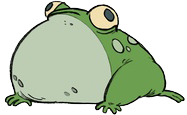

In [4]:
td

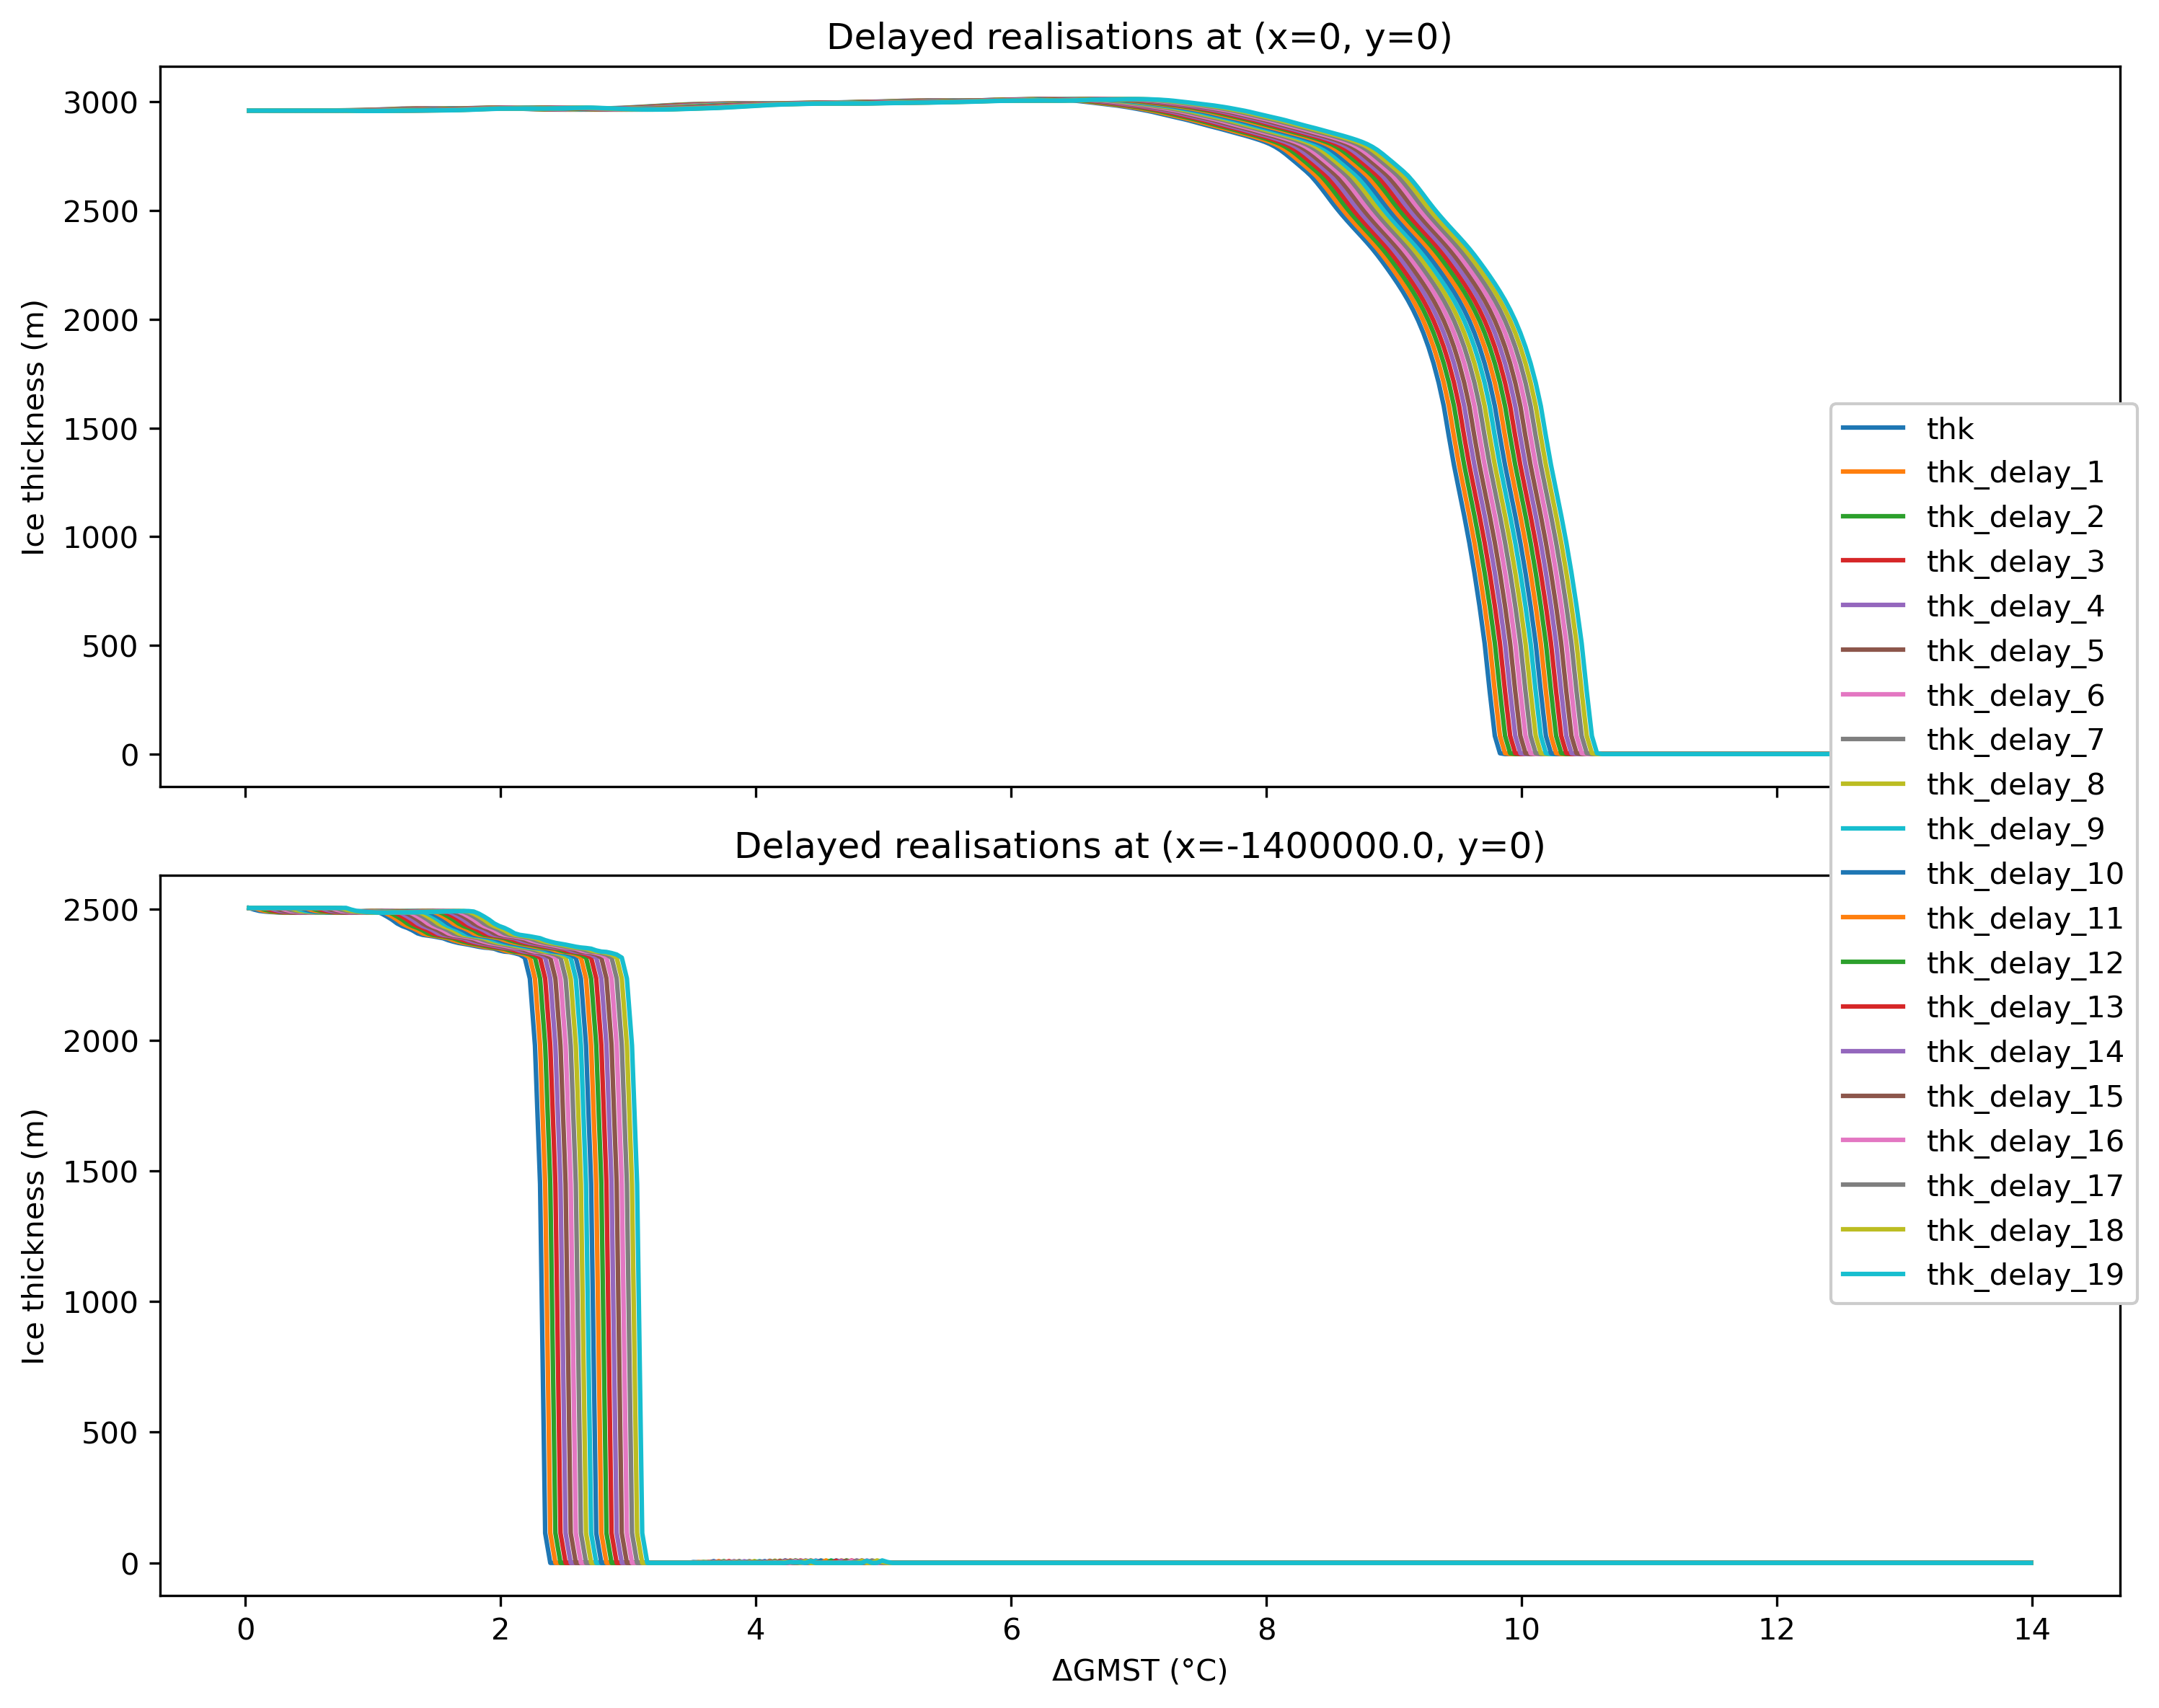

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

locations = [(0, 0), (-14e5, 0)]  # Example alternative locations, (x, y)

for idx, (x_val, y_val) in enumerate(locations):
    for var in td.base_vars:
        axs[idx].plot(
            td.data[td.time_dim],
            td.data[var].sel(x=x_val, y=y_val, method="nearest"),
            label=var,
        )
    axs[idx].set_ylabel("Ice thickness (m)")
    axs[idx].set_title(f"Delayed realisations at (x={x_val}, y={y_val})")
axs[-1].set_xlabel("ΔGMST (°C)")

# Create a common legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.0, 0.5), framealpha=1)

plt.tight_layout()
plt.show()

# Computes shifts and clusters


In [6]:
from sklearn.cluster import HDBSCAN
from toad.shifts import ASDETECT

td.drop_shifts()
for bvar in td.base_vars:
    td.compute_shifts(
        var=bvar, method=ASDETECT(timescale=(0.5, 3.5)), show_progress=False
    )

INFO: New shifts variable thk_dts: min/mean/max=-1.000/-0.226/1.000 using 3589 grid cells. Skipped 60.2% grid cells: 0 NaN, 5436 constant.
INFO: New shifts variable thk_delay_1_dts: min/mean/max=-1.000/-0.226/1.000 using 3589 grid cells. Skipped 60.2% grid cells: 0 NaN, 5436 constant.
INFO: New shifts variable thk_delay_2_dts: min/mean/max=-1.000/-0.225/1.000 using 3589 grid cells. Skipped 60.2% grid cells: 0 NaN, 5436 constant.
INFO: New shifts variable thk_delay_3_dts: min/mean/max=-1.000/-0.225/1.000 using 3589 grid cells. Skipped 60.2% grid cells: 0 NaN, 5436 constant.
INFO: New shifts variable thk_delay_4_dts: min/mean/max=-1.000/-0.225/1.000 using 3589 grid cells. Skipped 60.2% grid cells: 0 NaN, 5436 constant.
INFO: New shifts variable thk_delay_5_dts: min/mean/max=-1.000/-0.225/1.000 using 3589 grid cells. Skipped 60.2% grid cells: 0 NaN, 5436 constant.
INFO: New shifts variable thk_delay_6_dts: min/mean/max=-1.000/-0.225/1.000 using 3589 grid cells. Skipped 60.2% grid cells: 0

In [7]:
td.drop_clusters()
for svar in td.shift_vars:
    td.compute_clusters(
        var=svar,
        method=HDBSCAN(min_cluster_size=10),
        overwrite=True,
        time_weight=2.0,
        shift_direction="negative",
        shift_threshold=0.5,
    )

INFO: New cluster variable thk_dts_cluster: Identified 38 clusters in 3,869 pts; Left 33.8% as noise (1,306 pts).
INFO: New cluster variable thk_delay_1_dts_cluster: Identified 39 clusters in 3,866 pts; Left 31.4% as noise (1,212 pts).
INFO: New cluster variable thk_delay_2_dts_cluster: Identified 36 clusters in 3,863 pts; Left 32.6% as noise (1,260 pts).
INFO: New cluster variable thk_delay_3_dts_cluster: Identified 39 clusters in 3,848 pts; Left 32.0% as noise (1,232 pts).
INFO: New cluster variable thk_delay_4_dts_cluster: Identified 41 clusters in 3,841 pts; Left 33.5% as noise (1,285 pts).
INFO: New cluster variable thk_delay_5_dts_cluster: Identified 39 clusters in 3,849 pts; Left 36.3% as noise (1,399 pts).
INFO: New cluster variable thk_delay_6_dts_cluster: Identified 36 clusters in 3,855 pts; Left 29.4% as noise (1,135 pts).
INFO: New cluster variable thk_delay_7_dts_cluster: Identified 37 clusters in 3,842 pts; Left 28.8% as noise (1,106 pts).
INFO: New cluster variable thk_d

# Compute consensus


#### Required params:

**`min_consensus`**

Minimum **fraction of input clusterings** that must support a native event voxel (after tolerance dilation). With 20 inputs and `min_consensus=0.75`, a voxel needs support from at least **15** distinct inputs.

- **Higher** → stricter agreement; fewer retained voxels and often **smaller / more fragmented** consensus clusters.
- **Lower** → more voxels pass the threshold; often **larger / more merged** clusters.

**`temporal_tolerance`**

Different clusterings can place the **same shift event** one or a few timesteps apart. When counting support, each input’s event labels are dilated by **`±temporal_tolerance`** steps along time. The same tolerance is used when grouping retained voxels into connected consensus clusters.

- Intuition: **how much timing jitter** you allow when asking “do these runs agree on this event?”
- **`0`** → exact-time support only (connectivity still links immediate temporal neighbours via `max(1, tolerance)`).

**`spatial_tolerance`**

Similarly, runs may disagree slightly on **which grid cell** carries an event. Support counting dilates each input mask by **`±spatial_tolerance`** native-grid cells in `y`/`x`. The same tolerance governs spatial connectivity among retained voxels.

- **`0`** → only exactly overlapping spatial supports count when matching.
- **Larger** → nearby cells can support the same native event (helps with small spatial offsets), but values that are too large can **merge distinct** nearby events.

**`stitch_meridian`** (default `"auto"`)

On global longitude grids, TOAD can treat the first and last native-grid columns as neighbours during dilation and labelling. `"auto"` enables this when the grid spans nearly all longitudes; use `False` for regional domains.

**`min_cluster_area`** (optional post-filter)

After consensus, drops clusters whose **spatial footprint** (distinct grid cells that ever carry that cluster id) is **below** this threshold; those cells become noise (`-1`). The library default is **2** (removes single-cell clusters); the call below uses **`5`** for a stricter map. Use **`None`** to turn this filter off.


In [8]:
td.compute_consensus(
    min_consensus=0.75,  # -> 3/4 of input clusterings must agree
    temporal_tolerance=10,  # -> Allow for 10 time steps of jitter
    spatial_tolerance=0,  # -> Only exact spatial support counts
    min_cluster_area=5,  # -> Keep only consensus clusters with at least 5 grid cells
    overwrite=True,
)

member-support consensus: 100%|██████████| 20/20 [00:00<00:00, 52.81it/s]
INFO: New consensus variable cluster_consensus: Identified 29 consensus clusters over 3,158,750 spacetime cells; 0.91% shift noise / not in consensus (28,900 cells); 98.58% no abrupt shift (3,113,889 cells NaN).


The consensus summary table shows the main properties of each detected consensus cluster:

- `mean_consistency`: Mean member-support fraction over retained voxels in the cluster (higher = stronger cross-input agreement).
- `area` / `mean x/y`: Footprint and centroid location.
- `median_median_shift_time` / `std_median_shift_time`: Median of per-input spatial medians (and spread **between** input clusterings).
- `pooled_median_shift_time` / `pooled_std_shift_time`: Median and sample std of **all** transition-time samples in the long table (pooled over inputs: same as `td.plot.consensus_shift_times_violins(...)`).
- `median_std_shift_time` / `std_std_shift_time`: Typical **within-input** spread of transition times (“sharpness”) and how much that sharpness varies **between** inputs.


In [9]:
td.aggregate.consensus_summary()

,cluster_id,mean_consistency,area,mean_y,mean_x,median_median_shift_time,std_median_shift_time,median_std_shift_time,std_std_shift_time,pooled_median_shift_time,pooled_std_shift_time
0,0,0.891300,662,-4.127855e+05,1.287372e+06,8.2001,0.579672,0.846450,0.050416,8.4701,0.882679
1,1,0.875709,462,-2.537489e+05,-8.128485e+05,2.5101,0.180266,0.352749,0.103003,2.5101,0.396556
2,2,0.903686,264,1.244364e+06,9.020606e+05,9.4101,0.092973,0.463655,0.068691,9.4301,0.463812
3,3,0.902747,134,1.071881e+06,-3.379104e+04,7.6901,0.131697,0.165880,0.014907,7.6701,0.205101
4,4,0.877196,130,-1.696123e+06,9.603692e+05,4.2601,0.296869,0.429881,0.051281,4.1901,0.460129
5,5,0.862987,61,4.263607e+05,7.505574e+05,10.6901,0.248312,0.233142,0.068180,10.6701,0.294826
6,6,0.900139,46,-2.556522e+05,-1.972174e+05,12.4001,0.189660,0.339923,0.047803,12.4301,0.360837
7,7,0.872075,36,-1.000000e+06,-1.112000e+06,7.9501,0.279810,0.490027,0.175329,7.9501,0.487294
8,8,0.891189,43,-1.036465e+06,7.049302e+05,6.2001,0.051536,0.260351,0.064408,6.2301,0.264702
9,9,0.913677,28,1.850286e+06,-4.011428e+05,2.8201,0.092434,0.159441,0.062541,2.8701,0.184335


# Visualise consensus

**`consensus_overview`**: map of each consensus cluster plus a shift-time panel (default `kind=\"medians\"`; set `kind=\"violins\"` for pooled sample violins). **`consensus_timeseries`**: one consensus cluster’s aggregate behaviour against the delayed input series (here, median thickness along GMST).


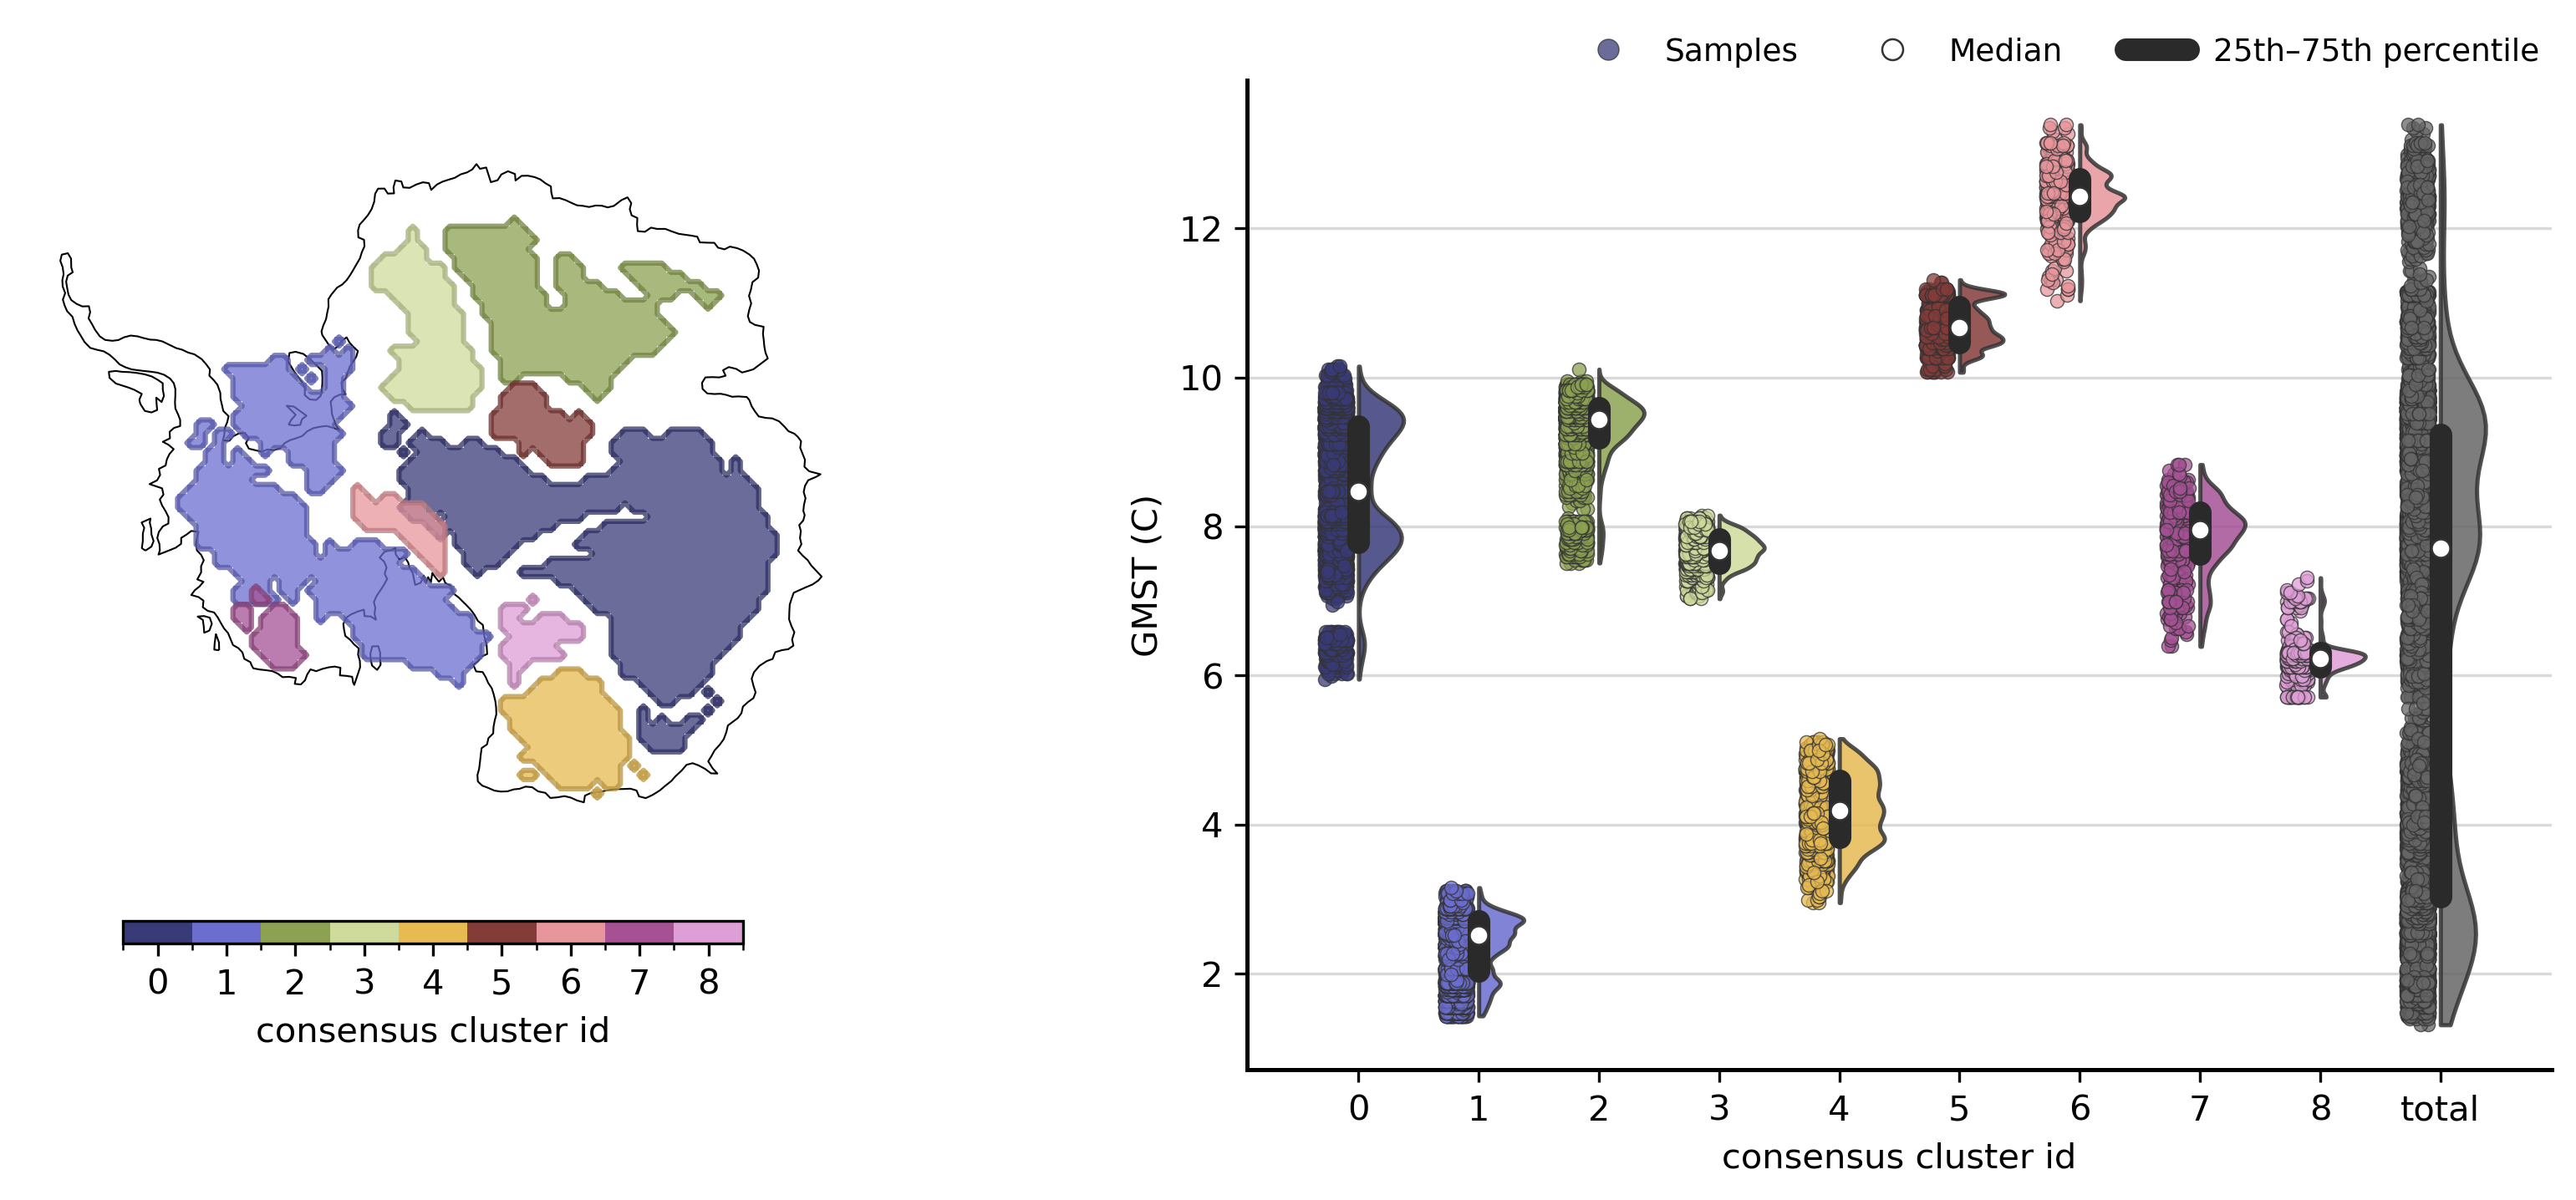

In [10]:
td.plot.consensus_overview(map_style=map_style, cluster_ids=range(9), kind="violins");


# Each can be plotted individually with:

# td.plot.consensus_shift_times_medians(...)
#     cluster_ids=range(9),
# )

# td.plot.consensus_map(
#     cluster_ids=range(8),
#     map_style=map_style,
# );

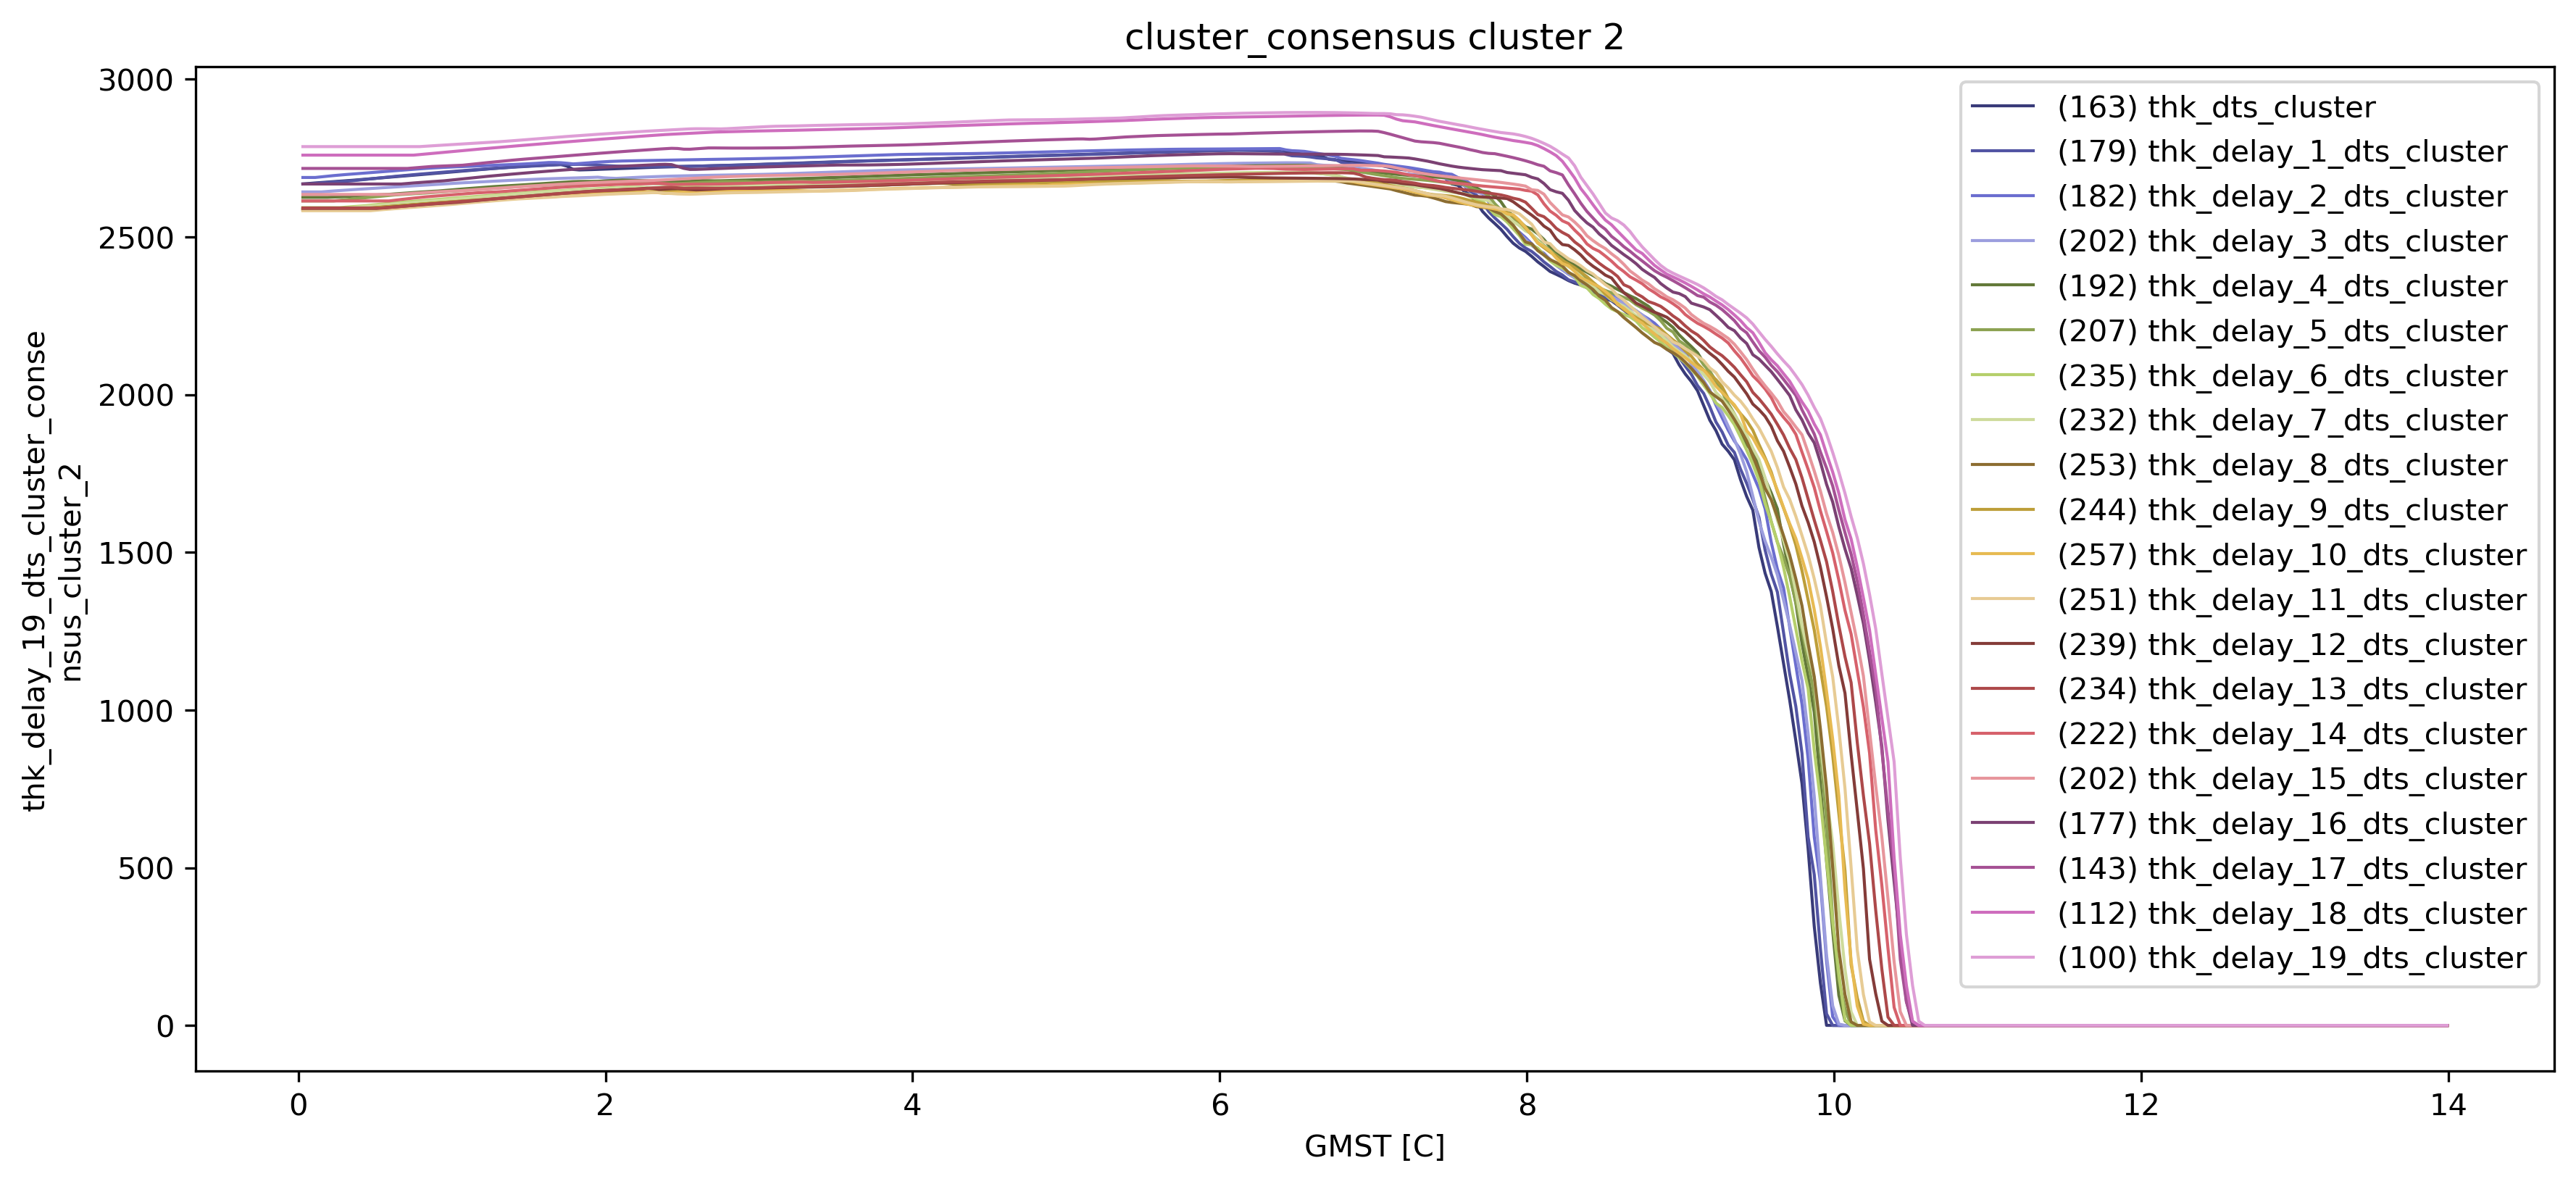

In [11]:
td.plot.consensus_timeseries(
    cluster_id=2, subplots=False, aggregation="median", figsize=(14, 6)
);

### Member support fraction map

The consensus label map shows **where** inputs agreed strongly enough to pass `min_consensus`. The companion field **`cluster_consensus_consistency`** stores the raw **member-support fraction** at every native **spacetime** event voxel—including places that fell **below** the threshold.

**`consensus_consistency_map`** collapses that field over time (default: **maximum** support at each grid cell) and masks cells where no input ever detected an event.

**Do not compare this directly to the cluster occurrence rate map.** Occurrence rate asks, for each grid cell, whether each input **ever** assigned a cluster there at **any** time (time is collapsed with OR logic; timing is not matched across inputs). Member support asks, at each native event timestep, what **fraction of inputs agreed on that spacetime event** after tolerance dilation. A cell can score `1.0` on occurrence because all runs flagged it at different times, while peak member support stays low because those events never overlap in time (even with `temporal_tolerance`). Conversely, bright regions here mark spacetime agreement, not merely recurring spatial hotspots.


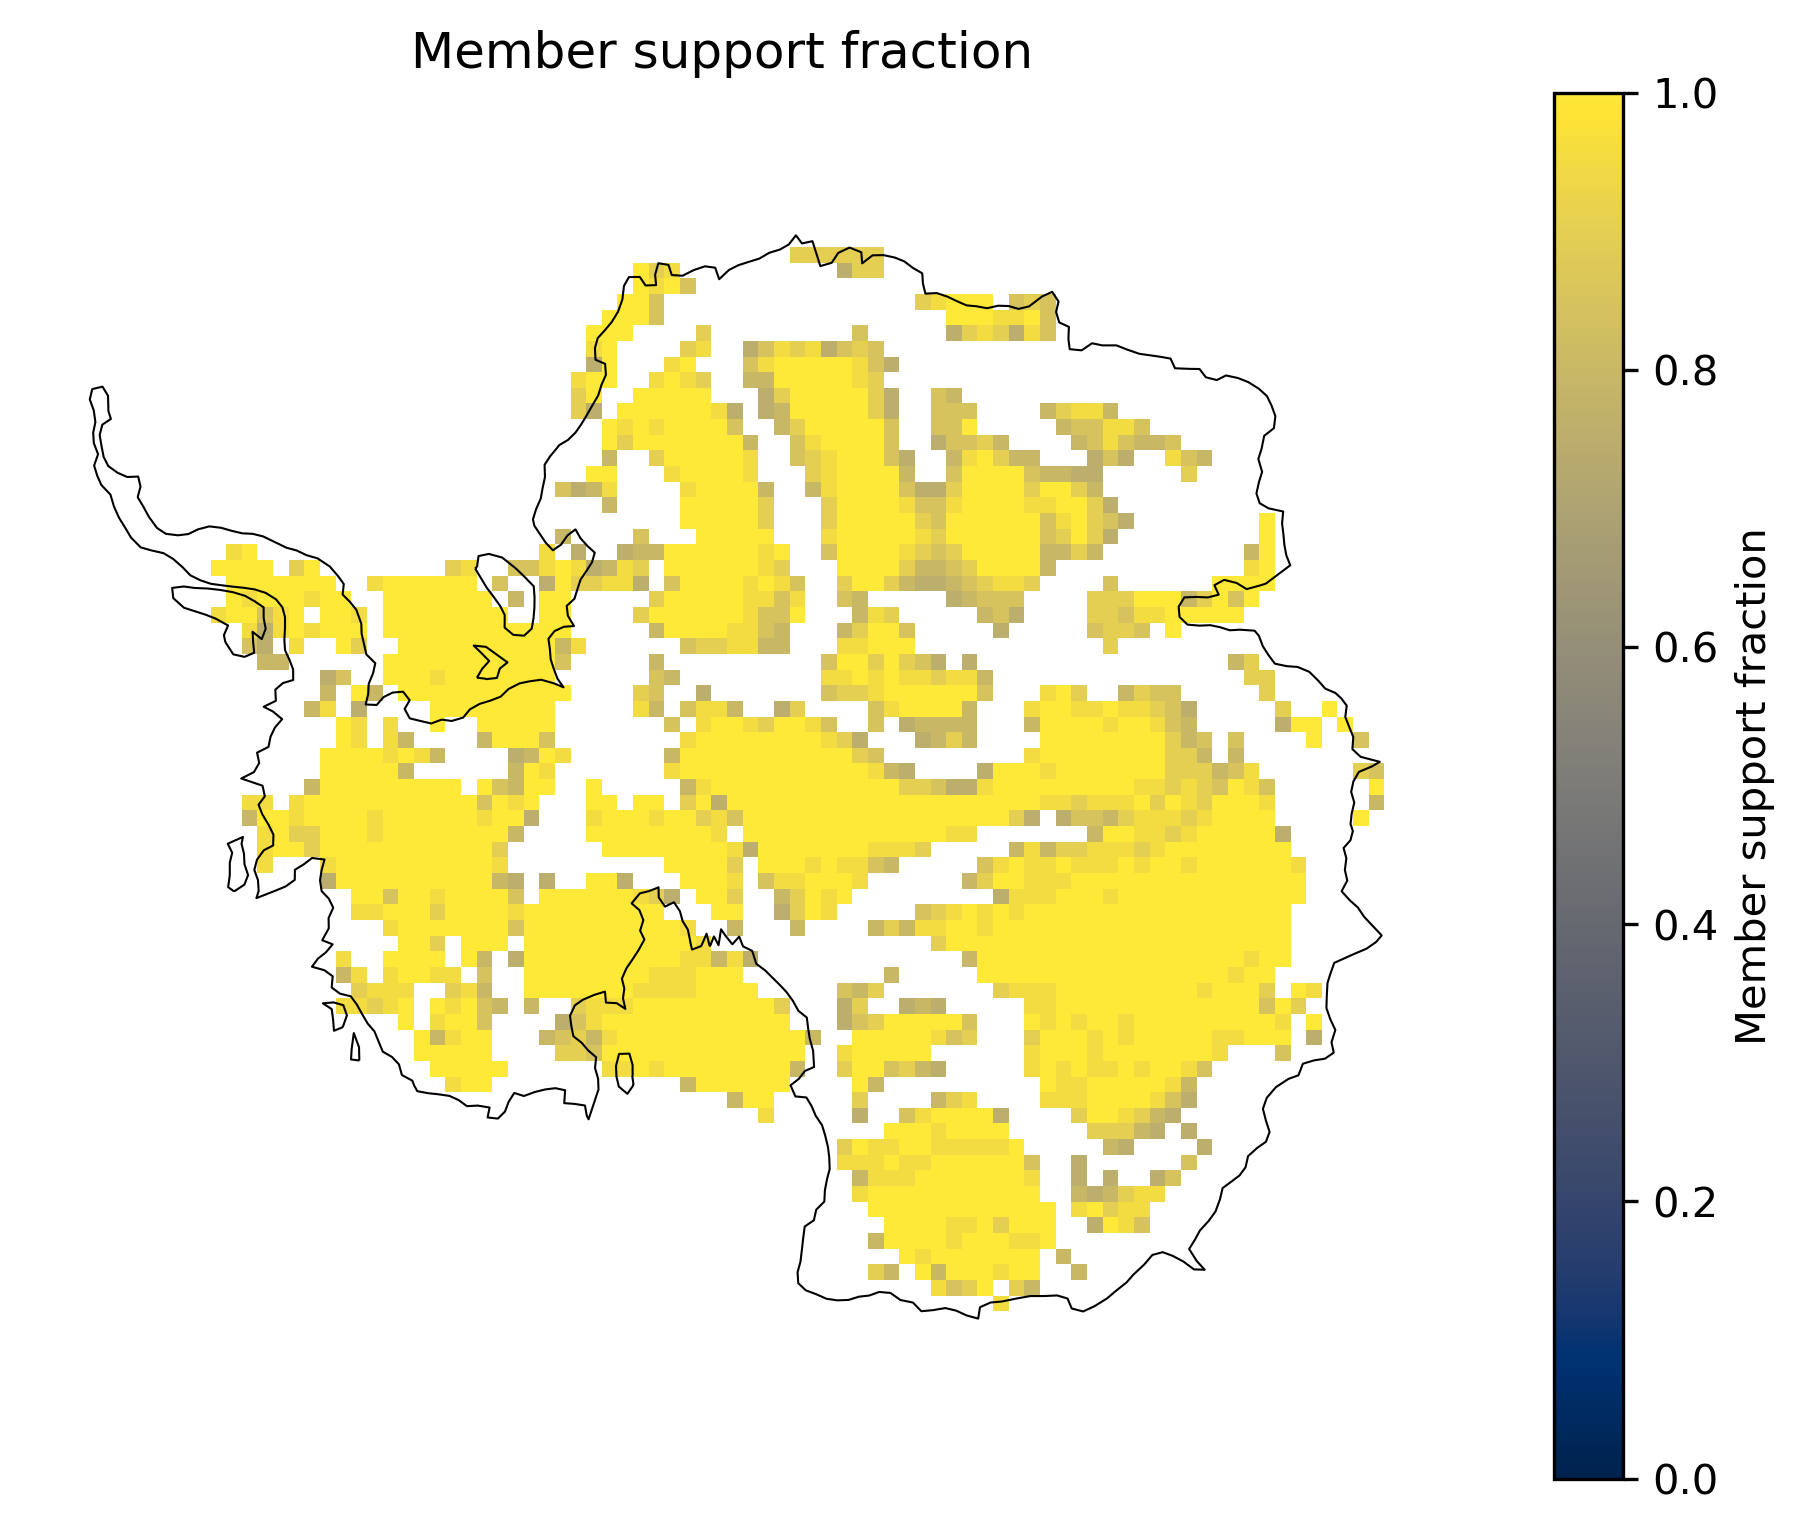

In [16]:
td.plot.consensus_consistency_map(map_style=map_style);

### Cluster occurrence rate (optional diagnostic)


Before or alongside consensus, a simple **cluster occurrence rate** map shows, at each grid cell, the fraction of input clusterings in which that cell was **ever** assigned to a cluster (collapsed over time). It highlights **where** shifts recur, but not **which cells cluster together**, **when** they shift, or **how many inputs agreed on the same event**—those questions need consensus and the member-support map above.


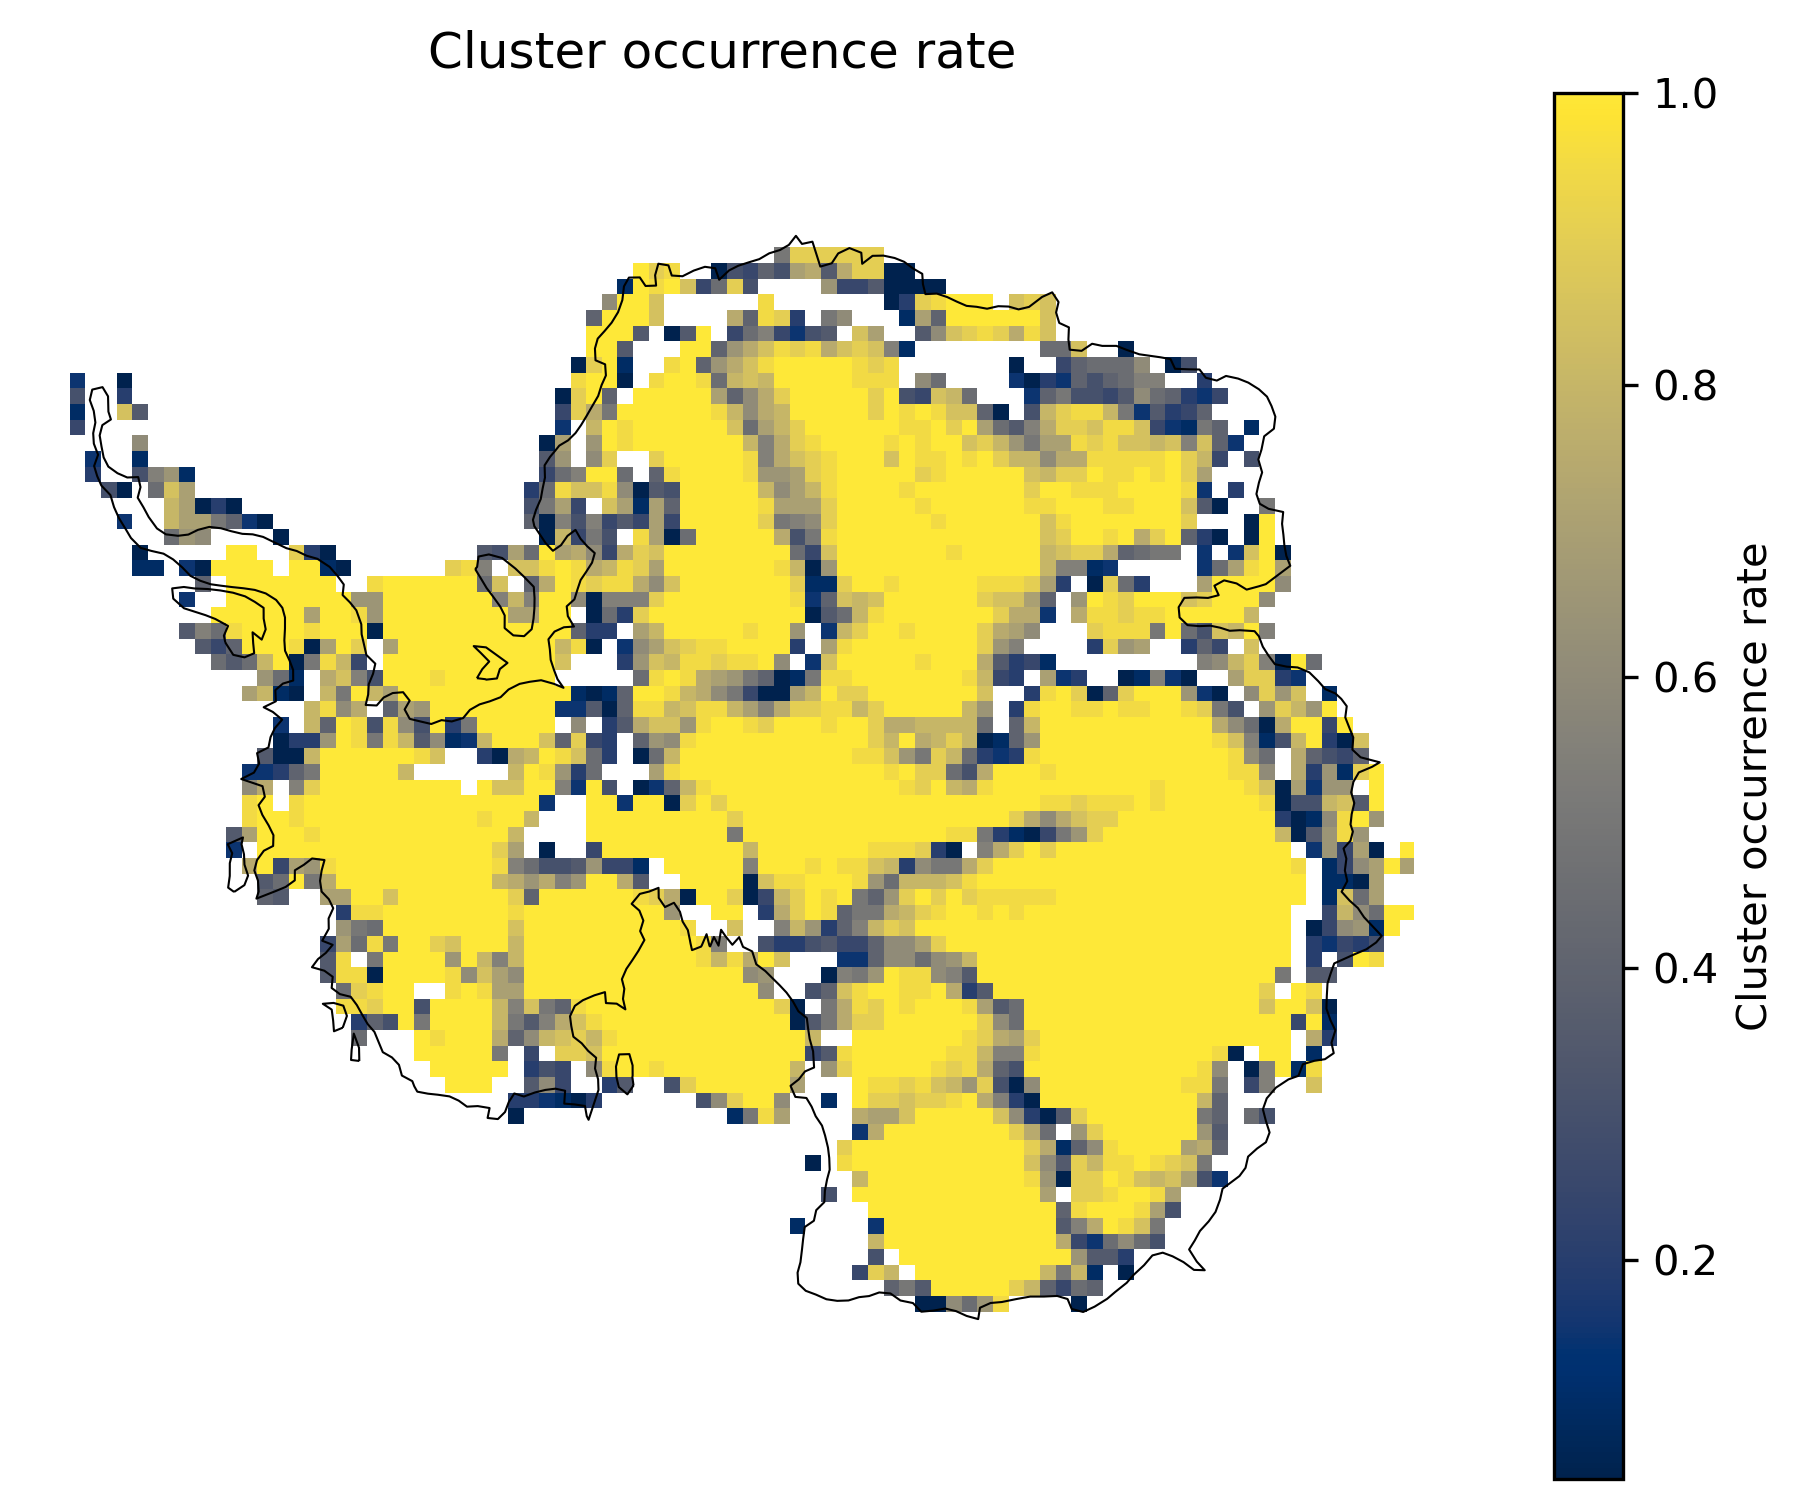

In [13]:
td.plot.cluster_occurrence_rate_map(map_style=map_style);